In [3]:
!pip install numpy

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare dataset

In [5]:
df = pd.read_csv('forestfires.csv')
df.head(5)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


## Preprocessing date

In [7]:
def convertMonth(month):
    dict = {
        'jan' : 1,
        'feb' : 2,
        'mar' : 3,
        'apr' : 4,
        'may' : 5,
        'jun' : 6,
        'jul' : 7,
        'aug' : 8,
        "sep" : 9,
        'oct' : 10,
        'nov' : 11,
        'dec' : 12
    }

    return dict[month]

In [8]:
def convertDay(day):
    dict = {
        'mon' : 0,
        'tue' : 1,
        'wed' : 2,
        'thu' : 3,
        'fri' : 4,
        'sat' : 5,
        'sun' : 6
    }

    return dict[day]

In [9]:
df['month'] = df['month'].apply(convertMonth)
df['day'] = df['day'].apply(convertDay)
df.head(5)

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,3,4,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,10,1,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,10,5,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,3,4,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,3,6,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


## Split train, test

In [10]:
# Covert dataframe -> numpy
data = df.to_numpy()

# Split train: 80%, test: 20%
train, test = np.split(data, [int(len(data)*0.8)])

# x_train cột đầu->cột kế cuối, y_train: cột cuối
x_train = train[:,:-1]
y_train = train[:,-1].reshape(-1,1)

x_test = test[:,:-1]
y_test = test[:,-1].reshape(-1,1)

print(x_train[:5])
print(f'Shape của tập train {x_train.shape} và {y_train.shape} \nShape của tập test {x_test.shape} và {y_test.shape}')

[[7.000e+00 5.000e+00 3.000e+00 4.000e+00 8.620e+01 2.620e+01 9.430e+01
  5.100e+00 8.200e+00 5.100e+01 6.700e+00 0.000e+00]
 [7.000e+00 4.000e+00 1.000e+01 1.000e+00 9.060e+01 3.540e+01 6.691e+02
  6.700e+00 1.800e+01 3.300e+01 9.000e-01 0.000e+00]
 [7.000e+00 4.000e+00 1.000e+01 5.000e+00 9.060e+01 4.370e+01 6.869e+02
  6.700e+00 1.460e+01 3.300e+01 1.300e+00 0.000e+00]
 [8.000e+00 6.000e+00 3.000e+00 4.000e+00 9.170e+01 3.330e+01 7.750e+01
  9.000e+00 8.300e+00 9.700e+01 4.000e+00 2.000e-01]
 [8.000e+00 6.000e+00 3.000e+00 6.000e+00 8.930e+01 5.130e+01 1.022e+02
  9.600e+00 1.140e+01 9.900e+01 1.800e+00 0.000e+00]]
Shape của tập train (413, 12) và (413, 1) 
Shape của tập test (104, 12) và (104, 1)


# Assignment 1

## Create Linear Model

In [11]:
class LinearRegression():
    def rmse(self, y, y_hat):
        delta = y-y_hat
        return (delta**2).mean()**0.5
    def fit(self,x,y):
        inv_conv = np.linalg.inv(x.T.dot(x))
        self.theta = inv_conv.dot(x.T.dot(y))
        return self.theta
    def predict(self, x):
        return x.dot(self.theta)

In [12]:
linear_alg = LinearRegression()
theta_ = linear_alg.fit(x_train, y_train)
print(theta_.shape)

(12, 1)


## Calculate test_output and loss

In [13]:
y_pred = linear_alg.predict(x_test)
loss = linear_alg.rmse(y_test, y_pred)
print(loss)

79.98777585416205


# Assingement 2

## Normalized Data

In [16]:
# Normalized từng feaeture
mean = np.mean(x_train, axis=0)
std = np.std(x_train, axis=0)

#NOTE: test cần được normalized dựa trên phân phối của tập train mà không được biết trước distribution
x_train_norm = (x_train-mean)/std
x_test_norm = (x_test-mean)/std


In [17]:
theta_ = linear_alg.fit(x_train_norm, y_train)
print(theta_)

[[ 2.46317464]
 [-0.46713689]
 [ 7.13136792]
 [ 3.86436936]
 [ 0.3101645 ]
 [ 5.80859765]
 [-6.66323982]
 [-4.36681955]
 [ 1.98980681]
 [-3.5536445 ]
 [ 0.15739031]
 [-0.66374029]]


## Calculate test_output and loss

In [18]:
y_pred = linear_alg.predict(x_test_norm)
loss = linear_alg.rmse(y_test, y_pred)
print(loss)

81.5059449025033


# Assignment 3

In [ ]:
#df.columns[:-1] lấy tất cả các cột trừ cột target
# np.zeros tạo ma trận có kích thước len(feature)*len(feature)
cov = np.zeros((len(df.columns[:-1]), len(df.columns[:-1])))
# np.corrcoef(x,y): tính ma trận correlation giữa x và y 
# Loop 2 vòng lặp so sánh mỗi feature này với tất cả feature còn lại
for i,col_name_i in enumerate(df.columns[:-1]):
    for j, col_name_j in enumerate(df.columns[:-1]):
        cov[i,j] = np.corrcoef(df[col_name_i].to_numpy(), df[col_name_j].to_numpy())[0,1]
cov

array([[ 1.00000000e+00,  5.39548171e-01, -6.50030324e-02,
        -2.49218945e-02, -2.10392720e-02, -4.83841781e-02,
        -8.59161229e-02,  6.20994073e-03, -5.12582619e-02,
         8.52231935e-02,  1.87978184e-02,  6.53871676e-02],
       [ 5.39548171e-01,  1.00000000e+00, -6.62917857e-02,
        -5.45333675e-03, -4.63075455e-02,  7.78156119e-03,
        -1.01177767e-01, -2.44879922e-02, -2.41030840e-02,
         6.22207310e-02, -2.03408517e-02,  3.32341032e-02],
       [-6.50030324e-02, -6.62917857e-02,  1.00000000e+00,
        -5.08365920e-02,  2.91476771e-01,  4.66645252e-01,
         8.68697759e-01,  1.86596974e-01,  3.68841505e-01,
        -9.52803843e-02, -8.63679653e-02,  1.34381291e-02],
       [-2.49218945e-02, -5.45333675e-03, -5.08365920e-02,
         1.00000000e+00, -4.10683308e-02,  6.28703973e-02,
         1.04902720e-04,  3.29092595e-02,  5.21903410e-02,
         9.21514374e-02,  3.24781638e-02, -4.83401530e-02],
       [-2.10392720e-02, -4.63075455e-02,  2.9147677

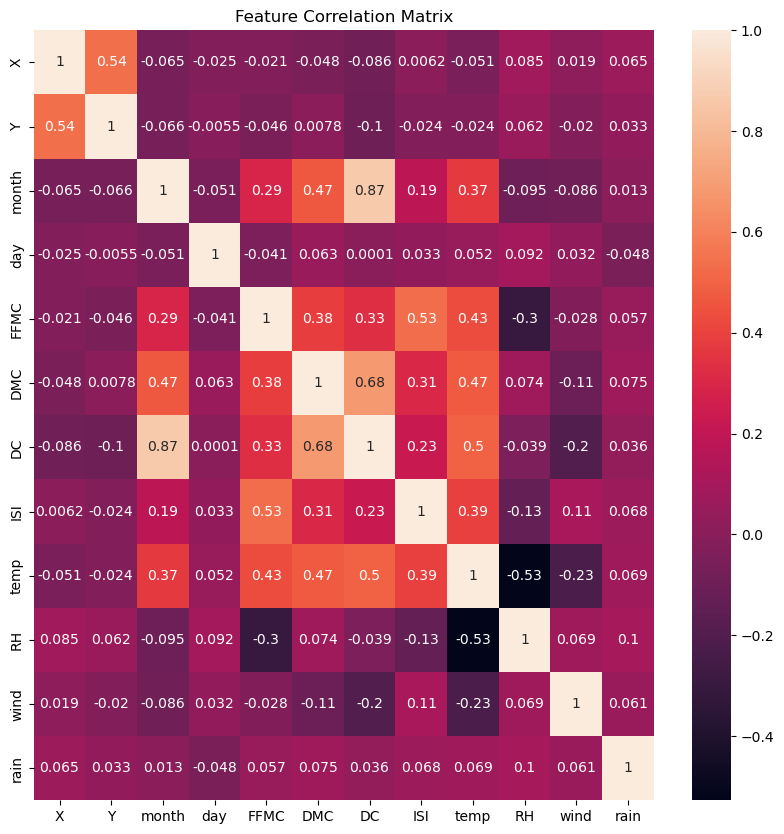

In [ ]:
plt.figure (figsize=(10,10))
# xticklabels = label của trục X.
# yticklabels = label của trục Y.
# annot hiển thị số trong heatmap
sns.heatmap(cov, xticklabels=df.columns[:-1], yticklabels=df.columns[:-1], annot=cov)
plt.title ("Feature Correlation Matrix");

# Assignent 4

In [ ]:
from sklearn.linear_model import LinearRegression
linear_reg = LinearRegression()
linear_reg.fit (x_train_norm, y_train)